# Análisis de Experiencia del Cliente — 29/06/2026

## Pregunta de negocio

**¿Cuál es la puntuación media dada por los usuarios a los alojamientos turísticos y qué porcentaje de alojamientos tienen una evaluación general superior a 80 en cada ciudad?**

Este notebook utiliza el dataset final generado después de las fases de **Data Cleaning, Data Transformation y Data Reduction**. Por tanto, no repite tareas de limpieza ni un EDA general.

El análisis se organiza en dos bloques:

1. **Respuesta directa a la pregunta de negocio.**
2. **Análisis complementario del área de Experiencia del Cliente.**

### Variables utilizadas

- `city`: ciudad del alojamiento.
- `review_scores_rating`: valoración general en escala de 0 a 100.
- `rating_above_80`: indica si la valoración es superior a 80.
- componentes de satisfacción: precisión, limpieza, check-in, comunicación y ubicación.

Los alojamientos sin valoración permanecen en el dataset final, pero se excluyen únicamente de los cálculos que requieren una puntuación válida.

## 1. Librerías y configuración visual

La paleta sigue el criterio visual acordado por el equipo:

- **azules:** análisis principal y comparaciones;
- **turquesa:** información válida o situación positiva;
- **amarillo:** referencia o punto destacado;
- **gris:** información neutra, ausente o contextual.

### 1.1 Librerías, paleta y estilo visual

In [47]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency, kruskal

sns.set_theme(style="whitegrid", context="notebook")

NAVY = "#1D5273"
TEAL = "#3FA0A9"
DARK = "#2D3439"
YELLOW = "#FFC43D"
GREY = "#9B9B9B"
LIGHT_GREY = "#E7E7E7"
WHITE = "#FFFFFF"
GRID = "#E2E2E2"

BLUE_CMAP = LinearSegmentedColormap.from_list(
    "stayspain_blues",["#B9D5E6", "#6FA8C7", NAVY],
)

plt.rcParams.update(
    {
        "figure.figsize": (11, 6),"figure.dpi": 110, "axes.titlesize": 14,"axes.titleweight": "bold", "axes.titlecolor": DARK,
        "axes.labelcolor": DARK,"axes.edgecolor": GREY,"axes.spines.top": False,"axes.spines.right": False,"xtick.color": DARK,
        "ytick.color": DARK,"grid.color": GRID,"figure.facecolor": WHITE,"axes.facecolor": WHITE,
    }
)

### 1.2 Funciones auxiliares

In [48]:
def blue_scale(size):
    """Devuelve una escala azul con contraste suficiente."""
    if size <= 1:
        return [NAVY]

    return [BLUE_CMAP(value) for value in np.linspace(0.25, 0.95, size)]


def add_bar_labels(ax, suffix="", decimals=2, offset=0.15):
    """Añade etiquetas al final de barras horizontales."""
    for patch in ax.patches:
        value = patch.get_width()
        y_pos = patch.get_y() + patch.get_height() / 2
        label = f"{value:.{decimals}f}{suffix}"

        ax.text(
            value + offset,y_pos,label,va="center",fontsize=9.5,color=DARK,
        )


def graphic_table(
    dataframe,title,formats=None,highlight_max=None,highlight_min=None,width=None,
):
    """Muestra una tabla compacta y estable en GitHub."""
    data = dataframe.copy()
    numeric_data = dataframe.copy()

    for column, format_text in (formats or {}).items():
        if column in data.columns:
            data[column] = data[column].map(
                lambda value: (
                    format_text.format(value)
                    if pd.notna(value)
                    else "—"
                )
            )

    rows, columns = data.shape
    width = width or max(8, columns * 1.65)
    height = max(2.4, rows * 0.42 + 1.5)

    fig, ax = plt.subplots(figsize=(width, height))
    ax.axis("off")

    table = ax.table(
        cellText=data.values,colLabels=data.columns,cellLoc="center",colLoc="center",loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, 1.35)

    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor(WHITE)

        if row == 0:
            cell.set_facecolor(NAVY)
            cell.set_text_props(color=WHITE, weight="bold")
        else:
            cell.set_facecolor(
                "#F7F9FA" if row % 2 else "#EEF3F6"
            )

    for column_name in highlight_max or []:
        if column_name not in numeric_data.columns:
            continue

        row_index = numeric_data[column_name].idxmax()
        row_position = numeric_data.index.get_loc(row_index) + 1
        column_position = data.columns.get_loc(column_name)

        table[(row_position, column_position)].set_facecolor("#CFE8E5")
        table[(row_position, column_position)].set_text_props(
            weight="bold"
        )

    for column_name in highlight_min or []:
        if column_name not in numeric_data.columns:
            continue

        row_index = numeric_data[column_name].idxmin()
        row_position = numeric_data.index.get_loc(row_index) + 1
        column_position = data.columns.get_loc(column_name)

        table[(row_position, column_position)].set_facecolor("#FFF0B8")
        table[(row_position, column_position)].set_text_props(
            weight="bold"
        )

    ax.set_title(title, pad=16)
    plt.tight_layout()
    plt.show()

## 2. Carga y validación mínima del dataset

Se carga exclusivamente el dataset final. Las comprobaciones siguientes verifican que las variables necesarias existen, que no hay alojamientos duplicados y que las escalas de valoración son coherentes.

In [49]:
def find_dataset():
    """Localiza el dataset desde la raíz o desde Scripts."""
    current = Path.cwd()
    candidates = [
        current / "Data" / "clean_dataset_29_06_2026.csv",
        current.parent / "Data" / "clean_dataset_29_06_2026.csv",
        current / "clean_dataset_29_06_2026.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "No se encontró clean_dataset_29_06_2026.csv."
    )


data_path = find_dataset()
df = pd.read_csv(data_path)
df["city"] = df["city"].str.strip().str.capitalize()

print(
    f"Dataset cargado: {df.shape[0]:,} filas "
    f"y {df.shape[1]} columnas"
)

Dataset cargado: 6,733 filas y 18 columnas


In [50]:
main_columns = [
    "apartment_id","city","review_scores_rating","rating_above_80",
]

satisfaction_columns = [
    "review_scores_accuracy","review_scores_cleanliness","review_scores_checkin","review_scores_communication","review_scores_location",
]

required_columns = main_columns + satisfaction_columns
missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: {missing_columns}"
    )

if df["apartment_id"].duplicated().any():
    raise ValueError(
        "El dataset contiene apartment_id duplicados."
    )

rating_is_valid = (
    df["review_scores_rating"].isna()
    | df["review_scores_rating"].between(0, 100)
)

if not rating_is_valid.all():
    raise ValueError(
        "review_scores_rating contiene valores fuera de 0–100."
    )

for column in satisfaction_columns:
    component_is_valid = (
        df[column].isna()
        | df[column].between(0, 10)
    )

    if not component_is_valid.all():
        raise ValueError(
            f"{column} contiene valores fuera de 0–10."
        )

df["rating_above_80"] = df["rating_above_80"].astype(
    "boolean"
)

rating_flag_is_coherent = (
    (
        df["review_scores_rating"].isna()
        & df["rating_above_80"].isna()
    )
    | (
        df["review_scores_rating"].notna()
        & (
            df["rating_above_80"]
            == (df["review_scores_rating"] > 80)
        )
    )
)

if not rating_flag_is_coherent.all():
    raise ValueError(
        "rating_above_80 no coincide con review_scores_rating."
    )

print(
    "Validación completada: columnas, duplicados, "
    "escalas y coherencia correctas."
)

Validación completada: columnas, duplicados, escalas y coherencia correctas.


## 3. Calidad y cobertura de las valoraciones

La cobertura no se interpreta como un KPI de satisfacción. Se utiliza como **indicador de calidad del dato** para contextualizar los resultados de cada ciudad.

In [51]:
customer_df = df.dropna(
    subset=[
        "city","review_scores_rating","rating_above_80",
    ]
).copy()

total_accommodations = df["apartment_id"].nunique()
rated_accommodations = customer_df["apartment_id"].nunique()
global_coverage = rated_accommodations / total_accommodations * 100

print(f"Alojamientos totales: {total_accommodations:,}")
print(f"Alojamientos con valoración: {rated_accommodations:,}")
print(f"Cobertura global: {global_coverage:.2f}%")

Alojamientos totales: 6,733
Alojamientos con valoración: 5,459
Cobertura global: 81.08%


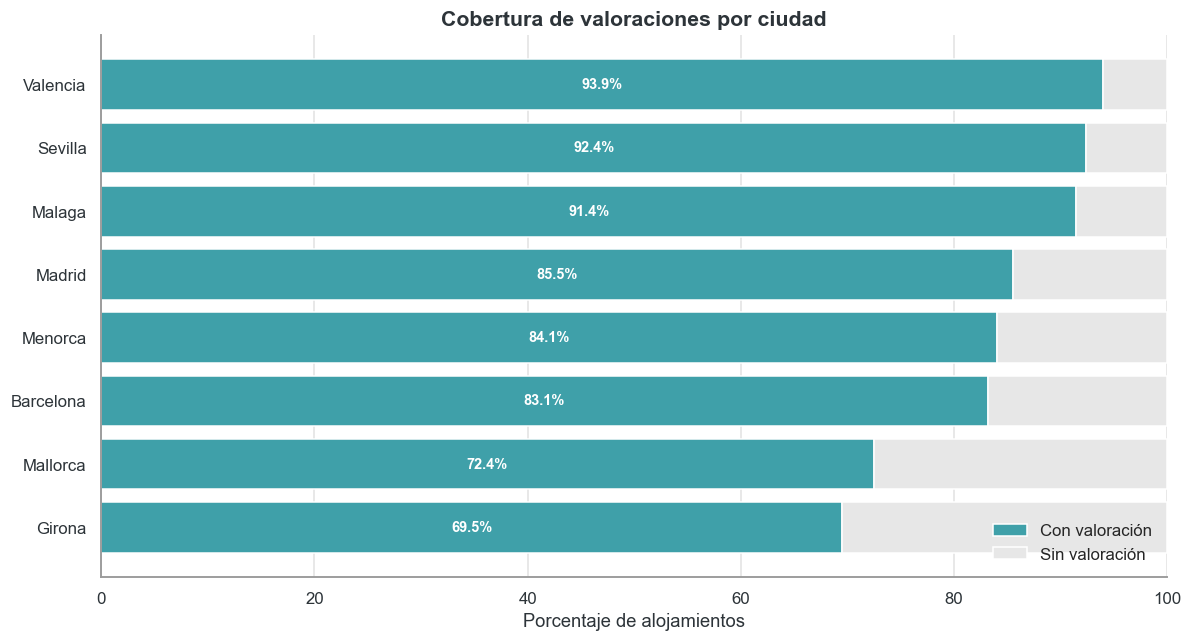

In [52]:
coverage_by_city = (
    df.groupby("city", as_index=False)
    .agg(
        total_accommodations=("apartment_id", "nunique"),
        rated_accommodations=("review_scores_rating","count",
        ),
    )
)

coverage_by_city["rating_coverage_pct"] = (
    coverage_by_city["rated_accommodations"]
    / coverage_by_city["total_accommodations"]
    * 100
)

coverage_by_city["without_rating_pct"] = (
    100 - coverage_by_city["rating_coverage_pct"]
)

coverage_plot = coverage_by_city.sort_values(
    "rating_coverage_pct"
)

fig, ax = plt.subplots()

ax.barh(
    coverage_plot["city"],coverage_plot["rating_coverage_pct"],color=TEAL,label="Con valoración",
)
ax.barh(
    coverage_plot["city"],coverage_plot["without_rating_pct"],
    left=coverage_plot["rating_coverage_pct"],color=LIGHT_GREY,label="Sin valoración",
)

for position, value in enumerate(
    coverage_plot["rating_coverage_pct"]
):
    ax.text(
        value / 2,
        position,
        f"{value:.1f}%",ha="center",va="center",color=WHITE,fontsize=9.5,fontweight="bold",
    )

ax.set(
    title="Cobertura de valoraciones por ciudad",xlabel="Porcentaje de alojamientos",ylabel="", xlim=(0, 100),
)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

### Conclusión

La cobertura de valoraciones es alta en la mayoría de las ciudades. Valencia, Sevilla y Málaga superan el 90%, mientras que Girona y Mallorca presentan la menor cobertura, por lo que sus resultados deben interpretarse con más cautela.

## 4. Respuesta a la pregunta de negocio

Se calculan los resultados solicitados:

- puntuación media de los alojamientos evaluados;
- número de alojamientos con puntuación superior a 80;
- porcentaje de alojamientos evaluados con puntuación superior a 80.

El denominador del porcentaje incluye únicamente alojamientos con una valoración general válida.

In [53]:
global_mean_rating = (
    customer_df["review_scores_rating"].mean()
)

global_percentage_over_80 = (
    customer_df["rating_above_80"].mean() * 100
)

city_summary = (
    customer_df.groupby("city", as_index=False)
    .agg(
        rated_accommodations=("apartment_id", "nunique"),
        average_rating=("review_scores_rating", "mean"),
        accommodations_over_80=("rating_above_80", "sum"),
        percentage_over_80=("rating_above_80", "mean"),
    )
)

city_summary["percentage_over_80"] *= 100

city_summary = city_summary.merge(
    coverage_by_city[
        [
            "city",
            "total_accommodations",
            "rating_coverage_pct",
        ]
    ],
    on="city",
    how="left",
)

city_summary = city_summary.sort_values(
    "average_rating",
    ascending=False,
).reset_index(drop=True)

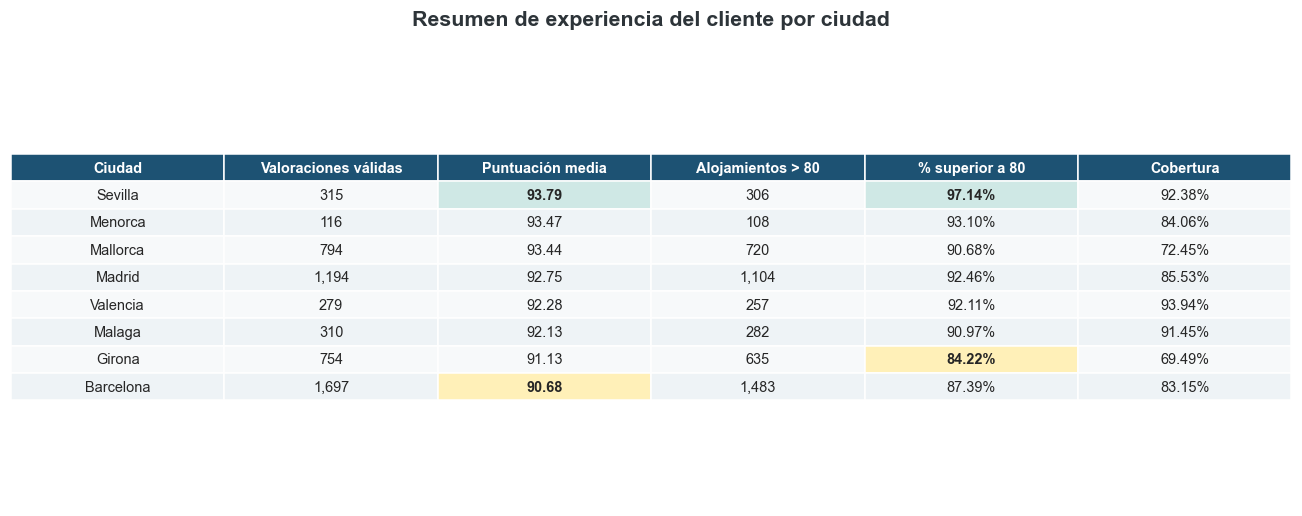

In [54]:
summary_table = city_summary.rename(
    columns={
        "city": "Ciudad",
        "rated_accommodations": "Valoraciones válidas",
        "average_rating": "Puntuación media",
        "accommodations_over_80": "Alojamientos > 80",
        "percentage_over_80": "% superior a 80",
        "rating_coverage_pct": "Cobertura",
    }
)

summary_table = summary_table[
    [
        "Ciudad","Valoraciones válidas","Puntuación media","Alojamientos > 80","% superior a 80","Cobertura",
    ]
]

graphic_table(
    summary_table,
    "Resumen de experiencia del cliente por ciudad",
    formats={
        "Valoraciones válidas": "{:,.0f}",
        "Puntuación media": "{:.2f}",
        "Alojamientos > 80": "{:,.0f}",
        "% superior a 80": "{:.2f}%",
        "Cobertura": "{:.2f}%",
    },
    highlight_max=[
        "Puntuación media","% superior a 80",
    ],
    highlight_min=[
        "Puntuación media","% superior a 80",
    ],
    width=12,
)

### Conclusión

Sevilla presenta los mejores resultados de satisfacción, con la puntuación media más alta y el mayor porcentaje de alojamientos por encima de 80. Barcelona registra la media más baja, mientras que Girona tiene el menor porcentaje superior a 80. Aun así, todas las ciudades mantienen niveles de satisfacción elevados.

### 4.1 Puntuación media por ciudad

La línea amarilla representa la media global. Los tonos azules expresan magnitud dentro del gráfico y no identifican ciudades concretas.

El eje está ampliado para facilitar la comparación entre ciudades; por tanto, las diferencias visuales deben interpretarse junto con los valores numéricos mostrados.

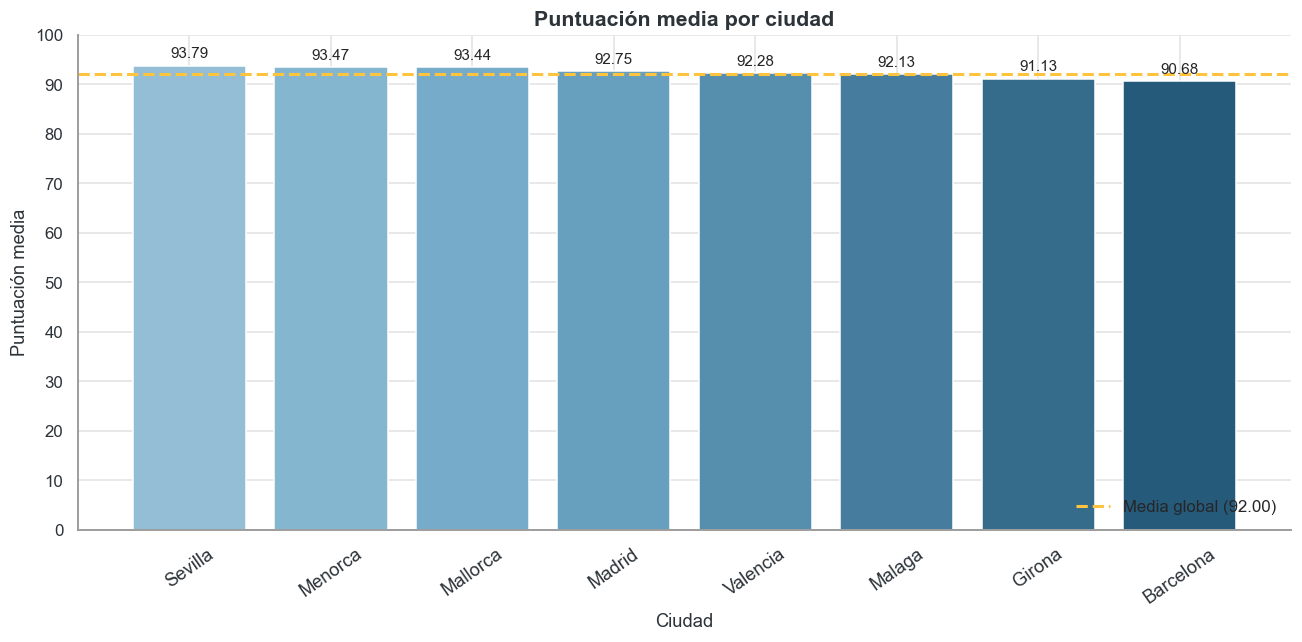

In [55]:
rating_plot = city_summary.sort_values(
    "average_rating",ascending=False
).copy()

rating_colors = blue_scale(len(rating_plot))

fig, ax = plt.subplots(figsize=(12, 6))

colors = blue_scale(len(rating_plot))

bars = ax.bar(
    rating_plot["city"],rating_plot["average_rating"],color=colors,
)

ax.axhline(
    global_mean_rating,color=YELLOW,linestyle="--",linewidth=2,label=f"Media global ({global_mean_rating:.2f})",
)

ax.bar_label(
    bars,fmt="%.2f",padding=3,fontsize=10,
)

ax.set(
    title="Puntuación media por ciudad",xlabel="Ciudad",ylabel="Puntuación media",ylim=(0, 100),
)

ax.set_yticks(range(0, 101, 10))

ax.tick_params(
    axis="x",labelsize=12,rotation=35,
)

ax.tick_params(
    axis="y",labelsize=11,
)

ax.legend(
    frameon=False,loc="lower right",
)

plt.tight_layout()
plt.show()

### Conclusión

La puntuación media global es de **92 puntos**. Sevilla, Menorca y Mallorca se sitúan por encima de esta media, mientras que Barcelona y Girona presentan los valores más bajos. Aun así, todas las ciudades mantienen puntuaciones superiores a 90.

### 4.2 Porcentaje de alojamientos con puntuación superior a 80

La comparación se realiza sobre los alojamientos que disponen de una valoración general válida.

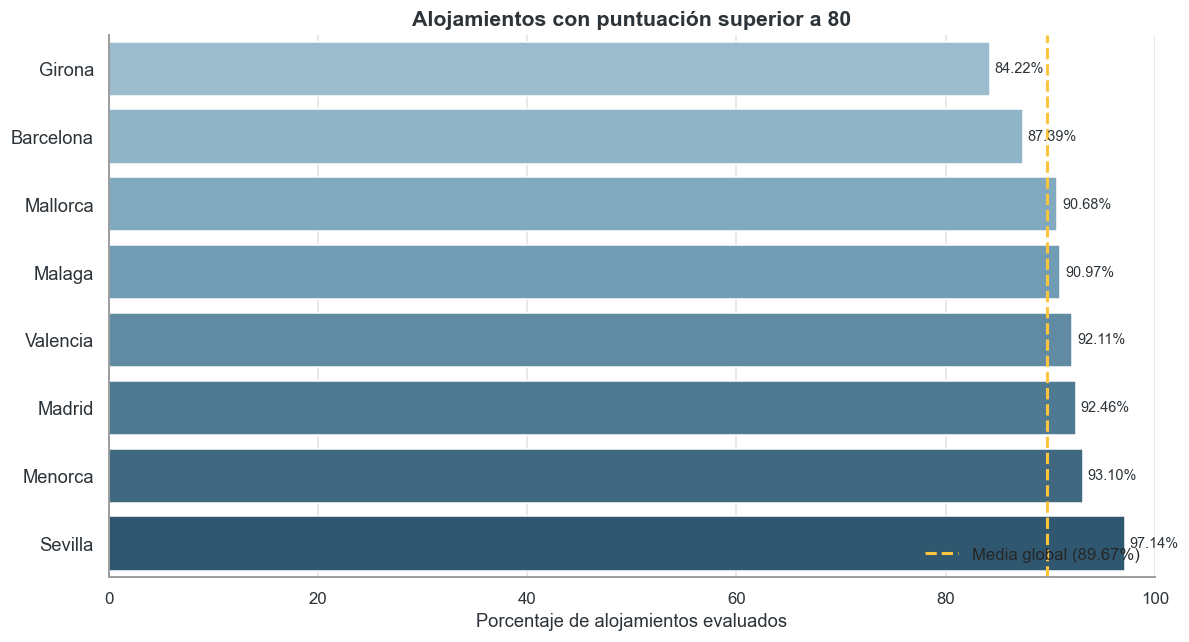

In [56]:
percentage_plot = city_summary.sort_values(
    "percentage_over_80"
).copy()

percentage_colors = blue_scale(len(percentage_plot))

fig, ax = plt.subplots()

sns.barplot(
    data=percentage_plot,x="percentage_over_80",y="city",hue="city",palette=percentage_colors,legend=False,ax=ax,
)

ax.axvline(
    global_percentage_over_80,color=YELLOW,linestyle="--",linewidth=2,
    label=(
        "Media global "
        f"({global_percentage_over_80:.2f}%)"
    ),
)

ax.set(
    title="Alojamientos con puntuación superior a 80",xlabel="Porcentaje de alojamientos evaluados",ylabel="",xlim=(0, 100),
)
ax.legend(frameon=False, loc="lower right")
add_bar_labels(
    ax,suffix="%",decimals=2,offset=0.45,
)

ax.tick_params(
    axis="y",labelsize=12,
)

plt.tight_layout()
plt.show()

### Conclusión

El **89.67%** de los alojamientos evaluados supera los 80 puntos. Sevilla presenta el porcentaje más alto (**97.14%**), mientras que Girona registra el más bajo (**84.22%**). En general, la mayoría de las ciudades se sitúa por encima de la media global.

## 5. Análisis complementario de Experiencia del Cliente

Este bloque amplía la respuesta principal sin duplicar el notebook de KPI ni el EDA general.

### 5.1 Distribución de las puntuaciones por ciudad

El box plot permite observar la mediana, la dispersión y los valores atípicos que no se perciben al comparar únicamente las medias.

El eje muestra la escala completa de 0 a 100 para evitar ocultar valoraciones bajas.

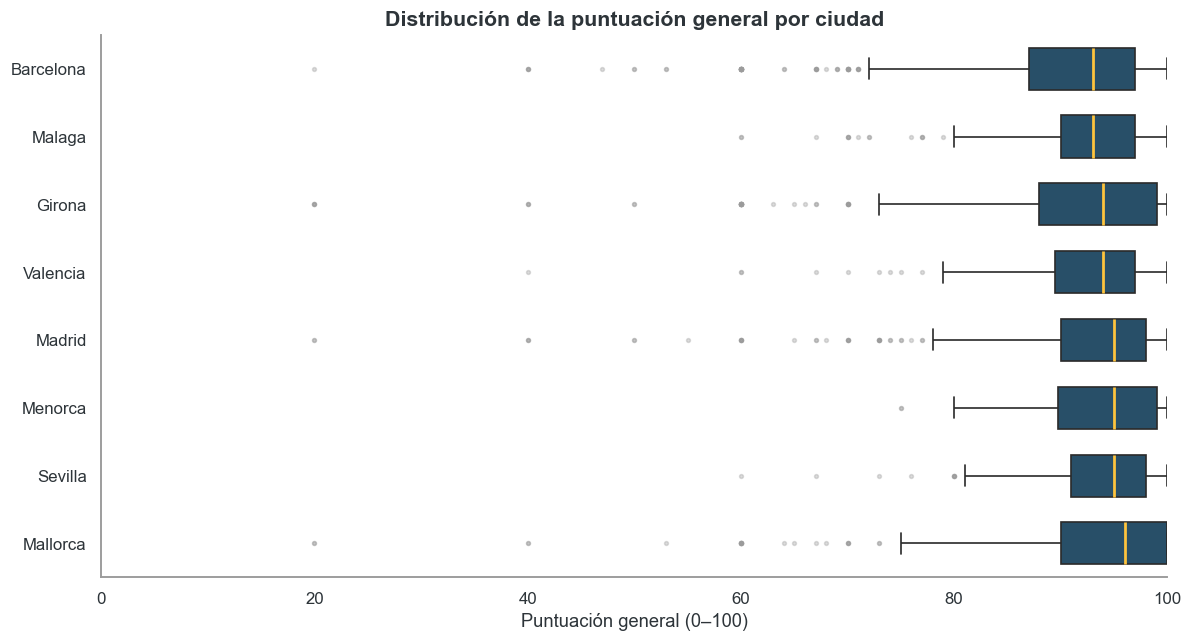

In [57]:
city_order = (
    customer_df.groupby("city")["review_scores_rating"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots()

sns.boxplot(
    data=customer_df,x="review_scores_rating",y="city",order=city_order,color=NAVY,width=0.62,linewidth=1.1,
    flierprops={
        "marker": "o","markersize": 2.5,"markerfacecolor": GREY,"markeredgecolor": GREY,"alpha": 0.35,
    },
    medianprops={
        "color": YELLOW,"linewidth": 1.8,
    },
    ax=ax,
)

ax.set(
    title="Distribución de la puntuación general por ciudad",xlabel="Puntuación general (0–100)",ylabel="",xlim=(0, 100),
)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Conclusión

Las puntuaciones se concentran en valores altos en todas las ciudades, con medianas cercanas o superiores a 90. Mallorca, Sevilla y Menorca muestran distribuciones especialmente favorables, mientras que Barcelona y Girona presentan mayor dispersión y más valores atípicos bajos.

### 5.2 Componentes de satisfacción

Se comparan precisión, limpieza, check-in, comunicación y ubicación. El componente con menor puntuación se destaca en amarillo como principal oportunidad de mejora.

La relación calidad-precio no se incluye porque esta variable no está disponible en el dataset final reducido.

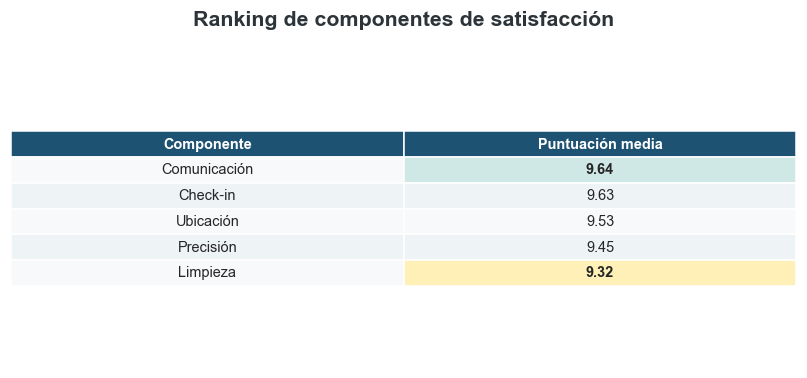

In [58]:
component_names = {
    "review_scores_accuracy": "Precisión","review_scores_cleanliness": "Limpieza","review_scores_checkin": "Check-in",
    "review_scores_communication": "Comunicación","review_scores_location": "Ubicación",
}

component_summary = (
    df[satisfaction_columns]
    .mean()
    .rename_axis("variable")
    .reset_index(name="Puntuación media")
)

component_summary["Componente"] = (
    component_summary["variable"].map(component_names)
)

component_summary = (
    component_summary[
        ["Componente", "Puntuación media"]
    ]
    .sort_values(
        "Puntuación media",
        ascending=False,
    )
    .reset_index(drop=True)
)

graphic_table(
    component_summary,"Ranking de componentes de satisfacción",formats={"Puntuación media": "{:.2f}"},
    highlight_max=["Puntuación media"],highlight_min=["Puntuación media"],width=7.5,
)

### Conclusión

La **comunicación** es el componente mejor valorado, seguida muy de cerca por el **check-in**. La **limpieza** presenta la puntuación más baja y constituye la principal oportunidad de mejora, aunque todos los componentes mantienen valores elevados.
```


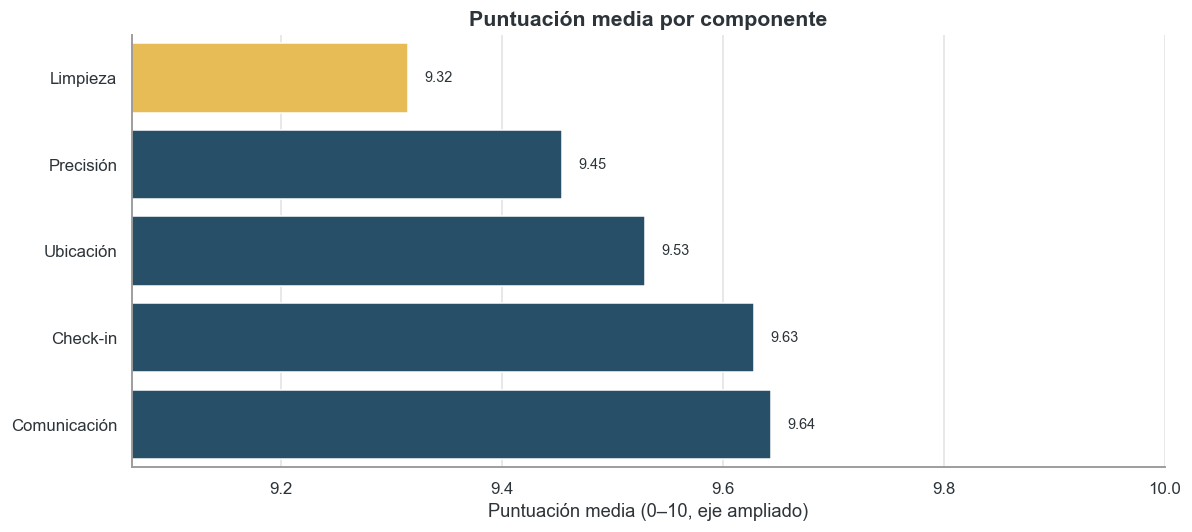

In [59]:
component_plot = component_summary.sort_values(
    "Puntuación media"
).copy()

lowest_component = component_plot.iloc[0]["Componente"]

component_colors = [
    YELLOW if component == lowest_component else NAVY
    for component in component_plot["Componente"]
]

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=component_plot,x="Puntuación media",y="Componente",hue="Componente",palette=component_colors,legend=False,ax=ax,
)

lower_limit = (
    component_plot["Puntuación media"].min() - 0.25
)

ax.set(
    title="Puntuación media por componente",xlabel="Puntuación media (0–10, eje ampliado)",ylabel="",xlim=(lower_limit, 10),
)
add_bar_labels(
    ax,decimals=2,offset=0.015,
)

plt.tight_layout()
plt.show()

### Conclusión

La **comunicación** y el **check-in** son los componentes mejor valorados. La **limpieza** obtiene la puntuación más baja y se identifica como la principal oportunidad de mejora, aunque todos los componentes superan los 9 puntos.

### 5.3 Componentes de satisfacción por ciudad

El mapa de calor permite identificar en qué dimensiones destaca cada ciudad y dónde se concentran las oportunidades de mejora.

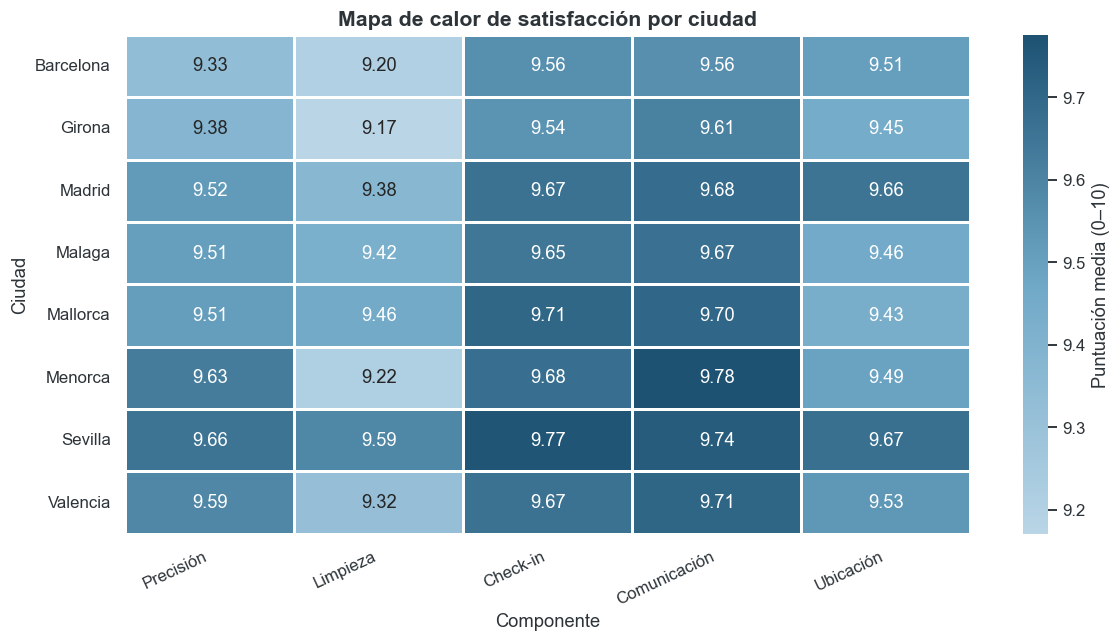

In [60]:
satisfaction_by_city = (
    df.groupby("city")[satisfaction_columns]
    .mean()
    .rename(columns=component_names)
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    satisfaction_by_city,annot=True,fmt=".2f",cmap=BLUE_CMAP,linewidths=0.8,linecolor=WHITE,
    cbar_kws={
        "label": "Puntuación media (0–10)"
    },
    ax=ax,
)

ax.set(
    title="Mapa de calor de satisfacción por ciudad",xlabel="Componente",ylabel="Ciudad",
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Conclusión

Sevilla presenta los resultados más altos en casi todos los componentes, mientras que Girona y Barcelona muestran valores algo más bajos, especialmente en limpieza. La comunicación y el check-in destacan como fortalezas generales en todas las ciudades.

## 6. Validación estadística

- **Kruskal–Wallis:** comprueba si la distribución de la puntuación general difiere entre ciudades.
- **Chi-cuadrado:** comprueba si la proporción de alojamientos por encima de 80 está asociada con la ciudad.

Las pruebas detectan diferencias o asociaciones, pero no demuestran causalidad.

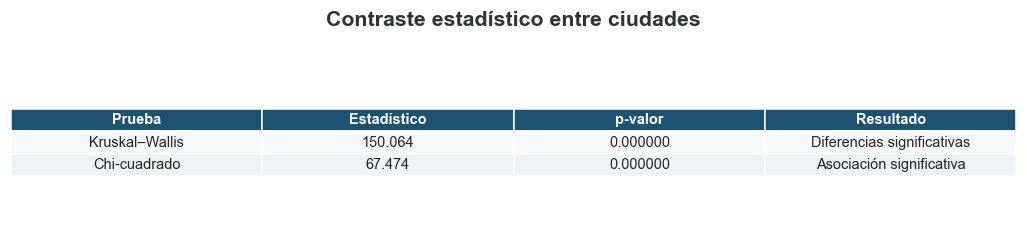

Cramér's V para ciudad × rating_above_80: 0.111


In [61]:
rating_groups = [
    group["review_scores_rating"].dropna().values
    for _, group in customer_df.groupby("city")
]

h_stat, p_kruskal = kruskal(*rating_groups)

contingency_table = pd.crosstab(
    customer_df["city"],
    customer_df["rating_above_80"],
)

chi2, p_chi2, degrees_freedom, _ = (
    chi2_contingency(contingency_table)
)

total_observations = contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2
    / (
        total_observations
        * min(contingency_table.shape[0] - 1, 1)
    )
)

test_results = pd.DataFrame(
    {
        "Prueba": [
            "Kruskal–Wallis","Chi-cuadrado",
        ],
        "Estadístico": [
            h_stat,chi2,
        ],
        "p-valor": [
            p_kruskal,p_chi2,
        ],
        "Resultado": [
            (
                "Diferencias significativas"
                if p_kruskal < 0.05
                else "No significativas"
            ),
            (
                "Asociación significativa"
                if p_chi2 < 0.05
                else "No significativa"
            ),
        ],
    }
)

graphic_table(
    test_results,
    "Contraste estadístico entre ciudades",
    formats={
        "Estadístico": "{:.3f}",
        "p-valor": "{:.6f}",
    },
    width=9.5,
)

print(
    "Cramér's V para ciudad × rating_above_80: "
    f"{cramers_v:.3f}"
)

### Conclusión

Las pruebas indican que existen diferencias estadísticamente significativas entre las ciudades, tanto en la distribución de las puntuaciones como en la proporción de alojamientos con valoración superior a 80. Sin embargo, la significancia estadística no implica que las diferencias sean grandes ni que la ciudad sea la causa directa.

## 7. Hallazgos principales

In [62]:
best_rating_city = city_summary.iloc[0]
worst_rating_city = city_summary.iloc[-1]

best_percentage_city = city_summary.loc[
    city_summary["percentage_over_80"].idxmax()
]

lowest_coverage_city = city_summary.loc[
    city_summary["rating_coverage_pct"].idxmin()
]

best_component = component_summary.iloc[0]
worst_component = component_summary.iloc[-1]

findings = [
    (
        "La puntuación media global es "
        f"{global_mean_rating:.2f}/100."
    ),
    (
        f"{global_percentage_over_80:.2f}% de los "
        "alojamientos evaluados supera 80 puntos."
    ),
    (
        f"{best_rating_city['city'].title()} presenta "
        "la puntuación media más alta "
        f"({best_rating_city['average_rating']:.2f}), "
        f"mientras que {worst_rating_city['city'].title()} "
        "registra la más baja "
        f"({worst_rating_city['average_rating']:.2f})."
    ),
    (
        f"{best_percentage_city['city'].title()} tiene "
        "el mayor porcentaje por encima de 80 "
        f"({best_percentage_city['percentage_over_80']:.2f}%)."
    ),
    (
        f"La cobertura más baja corresponde a "
        f"{lowest_coverage_city['city'].title()} "
        f"({lowest_coverage_city['rating_coverage_pct']:.2f}%)."
    ),
    (
        f"El componente mejor valorado es "
        f"{best_component['Componente']} "
        f"({best_component['Puntuación media']:.2f}/10) "
        f"y el más bajo es {worst_component['Componente']} "
        f"({worst_component['Puntuación media']:.2f}/10)."
    ),
]

for finding in findings:
    print(f"• {finding}")

• La puntuación media global es 92.00/100.
• 89.67% de los alojamientos evaluados supera 80 puntos.
• Sevilla presenta la puntuación media más alta (93.79), mientras que Barcelona registra la más baja (90.68).
• Sevilla tiene el mayor porcentaje por encima de 80 (97.14%).
• La cobertura más baja corresponde a Girona (69.49%).
• El componente mejor valorado es Comunicación (9.64/10) y el más bajo es Limpieza (9.32/10).


## 8. Conclusiones y recomendaciones

### Conclusiones

1. La satisfacción general es alta: la puntuación media global es de **92.00 sobre 100** y el **89.67%** de los alojamientos evaluados supera los 80 puntos.

2. **Sevilla** presenta los mejores resultados, tanto en puntuación media (**93.79**) como en porcentaje de alojamientos por encima de 80 (**97.14%**). **Barcelona** registra la puntuación media más baja (**90.68**), aunque mantiene un nivel de satisfacción elevado.

3. La **comunicación** es el componente mejor valorado (**9.64/10**), mientras que la **limpieza** obtiene la puntuación más baja (**9.32/10**) y representa la principal oportunidad de mejora.

4. Las diferencias entre ciudades son estadísticamente significativas. No obstante, la asociación entre ciudad y puntuación superior a 80 es débil, según el valor de **Cramér’s V = 0.111**.

5. Los resultados deben interpretarse junto con la cobertura de valoraciones, especialmente en **Girona**, que presenta la cobertura más baja (**69.49%**).

### Recomendaciones

- priorizar acciones de mejora relacionadas con la limpieza;
- reforzar la captación de valoraciones en las ciudades con menor cobertura;
- analizar los alojamientos con puntuaciones más bajas para detectar patrones comunes;
- complementar el análisis con variables disponibles como tipo de alojamiento, precio y ocupación antes de establecer relaciones causales.